# 73 - Human-Human Inter-Rater Agreement: Marmee vs. Kerem/Manav

Ralph asked specifically for a human-human kappa, distinct from the LLM-judge kappa computed in notebook 68. Kerem and Manav (Istari) independently reviewed 200 pooled candidates across 2 queries ("software companies" and "wealth management firms") and returned relevance labels (0/1/2). Marmee then blind-labeled the same 200 candidates, shuffled, no rank or prior label visible, using the same guidelines given to the LLM judges.

This notebook rebuilds the comparison, computes Cohen's kappa (3-class and binarized relevant/not-relevant), breaks it down per query, and plots the label distributions, confusion matrix, and disagreement patterns. All numbers here are meant to feed directly into the thesis's inter-annotator agreement section alongside notebook 68's results.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import cohen_kappa_score, confusion_matrix

OUTPUT_DIR = Path("result/73_kerem_manav_match_kappa")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## Part 1: Rebuild Kerem/Manav's labels in the same row order Marmee labeled them in

The blind file Marmee labeled (`kerem_manav_match_sample.xlsx`) was built from the two source export files with a fixed shuffle (`random_state=73`), so rebuilding the same shuffle here reproduces the exact row order she saw, with no label column, no rank column.

In [2]:
q1 = pd.read_excel("dataset/review_export_best100_q1_software_companies_labeled_.xlsx", sheet_name="review")
q1["query_id"] = 1
q1["query"] = "software companies"

q92 = pd.read_excel("dataset/review_export_best100_q92_wealth_management_firms_labeled_.xlsx", sheet_name="review")
q92["query_id"] = 92
q92["query"] = "wealth management firms"

combined = pd.concat([q1, q92], ignore_index=True)
combined = combined.rename(columns={"relevance_label": "kerem_manav_label"})

shuffled = combined.sample(frac=1, random_state=73).reset_index(drop=True)
reference = shuffled[["query_id", "query", "domain", "kerem_manav_label"]].copy()

print(f"reference rows: {len(reference)}")
reference.head()

reference rows: 200


,query_id,query,domain,kerem_manav_label
0,92,wealth management firms,cornerstoneplanninggroup.net,2
1,92,wealth management firms,hudsonfg.com,2
2,1,software companies,riiqo.com,2
3,1,software companies,trilobyte.de,2
4,92,wealth management firms,lanefamilywm.com,2


## Part 2: Load Marmee's blind labels and align with the reference

The assertion below guards against a silent row-order mismatch, if it fails, the two files are not aligned and the comparison below would be meaningless.

In [3]:
mine = pd.read_excel(OUTPUT_DIR / "kerem_manav_match_sample.xlsx")

assert (reference["domain"].values == mine["domain"].values).all(), "row order mismatch between blind file and rebuilt reference, do not proceed with a mismatched comparison"

merged = mine.merge(reference, on=["query_id", "query", "domain"])
merged["relevance_label"] = merged["relevance_label"].astype(int)
merged["kerem_manav_label"] = merged["kerem_manav_label"].astype(int)

print(f"merged rows: {len(merged)}")
merged.head()

merged rows: 200


,query_id,query,domain,name,organization_type,country,summary,relevance_label,kerem_manav_label
0,92,wealth management firms,cornerstoneplanninggroup.net,Cornerstone Planning Group,Company,United States,Cornerstone Planning Group is a financial plan...,2,2
1,92,wealth management firms,hudsonfg.com,Hudson Financial Group,Company,United States,Hudson Financial Group is a financial services...,2,2
2,1,software companies,riiqo.com,Big Software,Company,United States,Big Software offers a comprehensive customer m...,1,2
3,1,software companies,trilobyte.de,Trilobyte Software Engineering GmbH,Company,Germany,Trilobyte Software Engineering GmbH is a softw...,2,2
4,92,wealth management firms,lanefamilywm.com,Lane Family Wealth Management,Company,United States,Lane Family Wealth Management is a financial p...,2,2


## Part 3: Headline agreement metrics

In [4]:
m = merged["relevance_label"]
r = merged["kerem_manav_label"]

exact_agreement = (m == r).mean()
kappa_3class = cohen_kappa_score(m, r)

m_bin = (m >= 1).astype(int)
r_bin = (r >= 1).astype(int)
kappa_binary = cohen_kappa_score(m_bin, r_bin)

print(f"exact row-level agreement: {(m == r).sum()}/{len(merged)} ({exact_agreement:.1%})")
print(f"Cohen's kappa (3-class, 0/1/2): {kappa_3class:.3f}")
print(f"Cohen's kappa (binary, relevant vs. not): {kappa_binary:.3f}")

exact row-level agreement: 175/200 (87.5%)
Cohen's kappa (3-class, 0/1/2): 0.049
Cohen's kappa (binary, relevant vs. not): 0.000


## Part 4: Per-query breakdown

n=100 per query, so per-query kappa is noisier than the pooled number, still useful as a diagnostic since the two queries have different label skew.

In [5]:
per_query_rows = []
for qid, group in merged.groupby("query_id"):
    gm = group["relevance_label"]
    gr = group["kerem_manav_label"]
    per_query_rows.append({
        "query_id": qid,
        "query": group["query"].iloc[0],
        "n": len(group),
        "exact_agreement": (gm == gr).mean(),
        "kappa_3class": cohen_kappa_score(gm, gr),
    })

per_query = pd.DataFrame(per_query_rows)
per_query

,query_id,query,n,exact_agreement,kappa_3class
0,1,software companies,100,0.79,0.020979
1,92,wealth management firms,100,0.96,-0.015228


## Part 5: Label distributions and the kappa-paradox caveat

Kappa corrects for chance agreement assuming the label distribution is roughly known, when one class dominates heavily (here, "highly relevant" is ~95% of Kerem/Manav's labels), that correction can make kappa look misleadingly low even when raw agreement is high. This is a well-documented statistical artifact (the "kappa paradox"), not evidence that the labels are unreliable, worth stating explicitly in the thesis alongside the raw agreement figure and confusion matrix rather than reporting kappa in isolation.

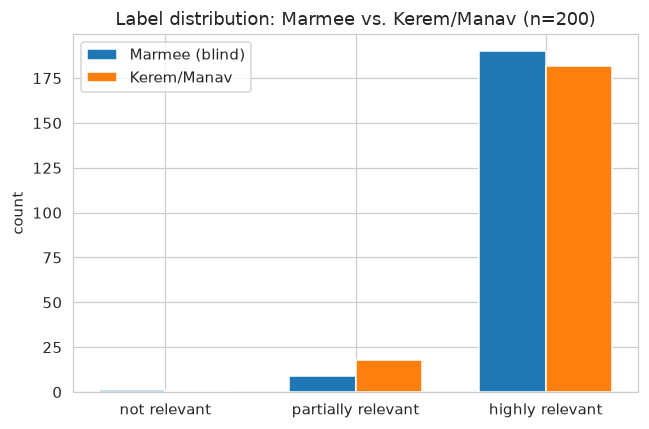

In [6]:
label_names = {0: "not relevant", 1: "partially relevant", 2: "highly relevant"}

dist_mine = m.value_counts().reindex([0, 1, 2], fill_value=0)
dist_ref = r.value_counts().reindex([0, 1, 2], fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, dist_mine.values, width, label="Marmee (blind)")
ax.bar(x + width / 2, dist_ref.values, width, label="Kerem/Manav")
ax.set_xticks(x)
ax.set_xticklabels([label_names[i] for i in [0, 1, 2]])
ax.set_ylabel("count")
ax.set_title("Label distribution: Marmee vs. Kerem/Manav (n=200)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution_comparison.png")
plt.show()

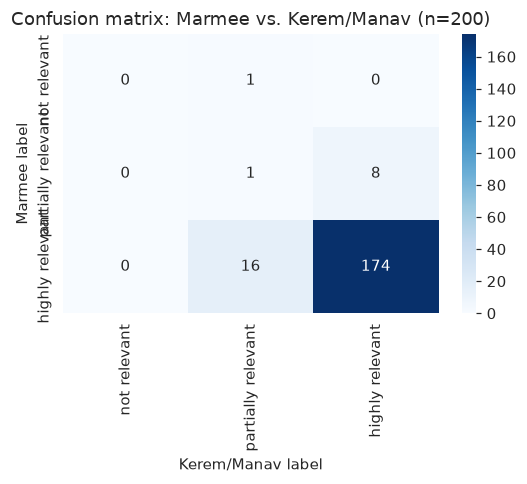

In [7]:
cm = confusion_matrix(m, r, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[label_names[i] for i in [0, 1, 2]], yticklabels=[label_names[i] for i in [0, 1, 2]], ax=ax)
ax.set_xlabel("Kerem/Manav label")
ax.set_ylabel("Marmee label")
ax.set_title("Confusion matrix: Marmee vs. Kerem/Manav (n=200)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png")
plt.show()

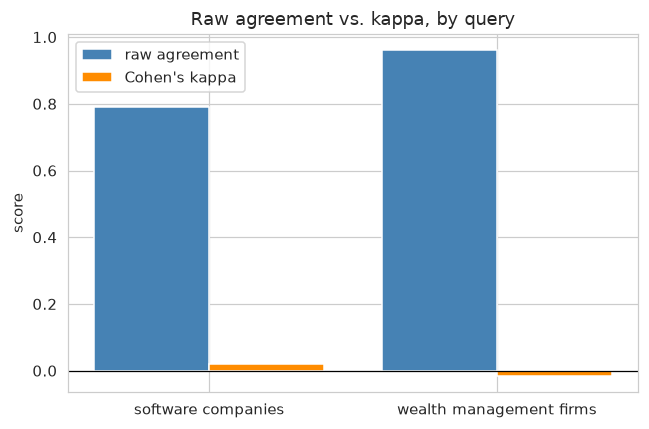

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(per_query))
ax.bar(x - 0.2, per_query["exact_agreement"], width=0.4, label="raw agreement", color="steelblue")
ax.bar(x + 0.2, per_query["kappa_3class"], width=0.4, label="Cohen's kappa", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(per_query["query"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("score")
ax.set_title("Raw agreement vs. kappa, by query")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_query_agreement_kappa.png")
plt.show()

## Part 6: Disagreement cases

Qualitative look at where Marmee and Kerem/Manav diverged, useful for a thesis discussion paragraph on what kind of cases the two disagree about (e.g. "partially" vs. "highly" relevant, rather than relevant vs. not relevant).

In [9]:
disagreements = merged[merged["relevance_label"] != merged["kerem_manav_label"]].copy()
disagreements["direction"] = np.where(disagreements["relevance_label"] < disagreements["kerem_manav_label"], "Marmee stricter", "Marmee looser")

print(f"{len(disagreements)} disagreements out of {len(merged)} ({len(disagreements) / len(merged):.1%})")
print(disagreements["direction"].value_counts())

disagreements_out = disagreements[["query_id", "query", "domain", "name", "relevance_label", "kerem_manav_label", "direction"]]
disagreements_out.to_csv(OUTPUT_DIR / "disagreements.csv", index=False)
disagreements_out

25 disagreements out of 200 (12.5%)
direction
Marmee looser      16
Marmee stricter     9
Name: count, dtype: int64


,query_id,query,domain,name,relevance_label,kerem_manav_label,direction
2,1,software companies,riiqo.com,Big Software,1,2,Marmee stricter
7,1,software companies,softwaremerchant.com,Software Merchant Inc.,2,1,Marmee looser
21,92,wealth management firms,fairhavencap.com,Fair Haven Capital,1,2,Marmee stricter
32,1,software companies,majicsourcesoftware.com.au,majicSource Software,1,2,Marmee stricter
35,1,software companies,fluxatron.com,fluxatron softec GmbH,1,2,Marmee stricter
36,1,software companies,agrisoftllc.com,"AgriSoft, LLC",1,2,Marmee stricter
50,1,software companies,hua-mi.cn,华米软件网 (Huami Software Network),0,1,Marmee stricter
61,1,software companies,rampgroup.com,Digitally transform your business.,2,1,Marmee looser
70,92,wealth management firms,maximgrp.com,"Maxim Group, LLC",2,1,Marmee looser
73,1,software companies,jbsoft.com.br,JB Software,1,2,Marmee stricter


## Summary for the thesis

In [10]:
summary = {
    "n": int(len(merged)),
    "exact_agreement": float(exact_agreement),
    "kappa_3class": float(kappa_3class),
    "kappa_binary": float(kappa_binary),
    "n_disagreements": int(len(disagreements)),
    "per_query": per_query.to_dict(orient="records"),
}

with open(OUTPUT_DIR / "summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'n': 200,
 'exact_agreement': 0.875,
 'kappa_3class': 0.049068086724990634,
 'kappa_binary': 0.0,
 'n_disagreements': 25,
 'per_query': [{'query_id': 1,
   'query': 'software companies',
   'n': 100,
   'exact_agreement': 0.79,
   'kappa_3class': 0.020979020979020935},
  {'query_id': 92,
   'query': 'wealth management firms',
   'n': 100,
   'exact_agreement': 0.96,
   'kappa_3class': -0.015228426395939021}]}

### Notes for writing this up

- Lead with raw agreement (87.5% in the last run), then kappa, then explain the kappa paradox immediately, since the two numbers look contradictory without that context.
- Report kappa as a pooled, single number across both queries, the per-query split is diagnostic only, n=100 per query is too small to report separately as a headline figure.
- The disagreement direction (Marmee stricter vs. looser) is worth one sentence, if disagreements cluster in one direction it suggests a calibration gap between reviewers rather than random noise.
- This result is a second, independent kappa alongside notebook 68's LLM-human and LLM-LLM numbers, cite both together in the inter-annotator agreement section rather than in isolation.